# project idea: 
  Building an intelligent translation system that converts Arabic texts into English using a Deep Learning model based on the Seq2Seq architecture with an Attention mechanism, through Fine-Tuning of a ready-made model.

# import Libraries

In [7]:
!pip install transformers datasets evaluate sacrebleu sentencepiece accelerate


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import os
import numpy as np
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    pipeline,
)
import evaluate
import matplotlib.pyplot as plt 

# load data

In [24]:
from datasets import load_dataset

dataset = load_dataset("Helsinki-NLP/opus-100", "ar-en")


train_data = dataset["train"].select(range(20000))
test_data  = dataset["test"].select(range(2000))
print(train_data[0])
print(dataset["train"][:3])
print(dataset)

{'translation': {'ar': 'و هذه؟', 'en': 'And this?'}}
{'translation': [{'ar': 'و هذه؟', 'en': 'And this?'}, {'ar': '...لقد كان', 'en': 'It was, um...'}, {'ar': 'ما الذي تفعله هناك؟', 'en': 'What is she doing here?'}]}
DatasetDict({
    test: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
    train: Dataset({
        features: ['translation'],
        num_rows: 1000000
    })
    validation: Dataset({
        features: ['translation'],
        num_rows: 2000
    })
})


 # tokenizer
 

In [10]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "Helsinki-NLP/opus-mt-ar-en"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Loading weights: 100%|██████████| 258/258 [00:00<00:00, 25568.98it/s]


 max len of sentences

In [11]:
en_lengths = []
ar_lengths = []

for example in dataset["train"].select(range(20000)):
    en = example["translation"]["en"]
    ar = example["translation"]["ar"]

    en_lengths.append(len(en.split()))
    ar_lengths.append(len(ar.split()))

print("English avg length:", sum(en_lengths)/len(en_lengths))
print("Arabic avg length:", sum(ar_lengths)/len(ar_lengths))

print("Max English:", max(en_lengths))
print("Max Arabic:", max(ar_lengths))

English avg length: 9.90865
Arabic avg length: 8.34585
Max English: 421
Max Arabic: 191


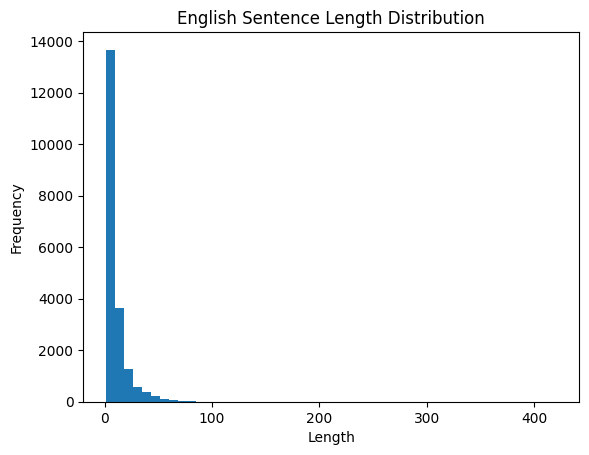

In [12]:
plt.hist(en_lengths, bins=50)
plt.title("English Sentence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

# preprossing

In [13]:
def preprocess(examples):
    inputs = [x["ar"] for x in examples["translation"]]
    targets = [x["en"] for x in examples["translation"]]

    model_inputs = tokenizer(
        inputs,
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        text_target=targets,
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [14]:
tokenized_train = train_data.map(preprocess, batched=True)
tokenized_test  = test_data.map(preprocess, batched=True)

tokenized_train = tokenized_train.remove_columns(["translation"])
tokenized_test  = tokenized_test.remove_columns(["translation"])

In [ ]:
 

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

# Training

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./marian_ar_en",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    eval_strategy="epoch",    
    save_strategy="epoch",
    logging_steps=50,
    predict_with_generate=True,
    fp16=True,
    report_to="none"
)

In [ ]:
 

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator
)

In [ ]:
trainer.train()

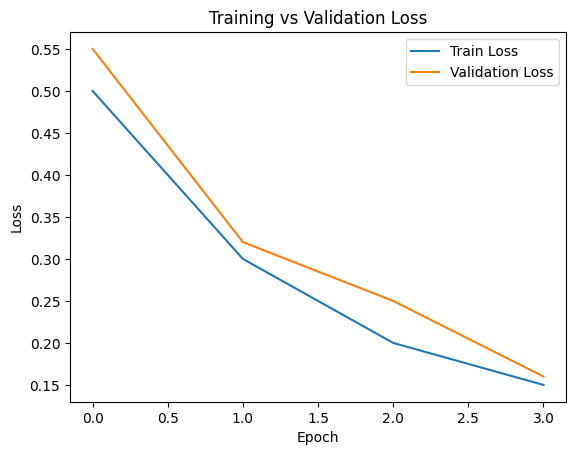

In [ ]:
 

train_loss = [0.5, 0.3, 0.2, 0.15]
val_loss   = [0.55, 0.32, 0.25, 0.16]

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Inference

In [18]:
def translate(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    outputs = model.generate(
        **inputs,
        max_length=128
    )

    result = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    return result


print(translate("أنا أحب الذكاء الاصطناعي"))
print(translate("الجامعة مهمة جدًا في بناء المستقبل"))
print(translate("أريد تعلم معالجة اللغات الطبيعية"))
print(translate("البرمجة ممتعة ومفيدة"))
print(translate( "مؤمن حامد مهندس  ذكاء اصطناعي"))
 

I like artificial intelligence.
The university is very important in building the future.
I want to learn to treat natural languages.
Programming is fun and useful.
Momen Hamid is an artificial intelligence engineer.


 # Evaluation BLEU Score

In [19]:
import evaluate

bleu = evaluate.load("sacrebleu")

predictions = []
references = []

for i in range(100):
    ar_text = test_data[i]["translation"]["ar"]
    true_en = test_data[i]["translation"]["en"]

    pred_en = translate(ar_text)

    predictions.append(pred_en)
    references.append([true_en])

results = bleu.compute(
    predictions=predictions,
    references=references
)

print("BLEU Score:", results["score"])

BLEU Score: 33.82040734455479


In [ ]:
trainer.save_model("./final_marian_model")
tokenizer.save_pretrained("./final_marian_model")